# 🔍 Módulo 14: Interpretação de Modelos (XAI)

## Objetivos de Aprendizagem

Ao final deste módulo, você será capaz de:

- ✅ Compreender a necessidade de **Explainable AI (XAI)** em aplicações reais
- ✅ Calcular e interpretar **Feature Importance** (MDI e Permutação)
- ✅ Criar e interpretar **Partial Dependence Plots (PDP)**
- ✅ Usar **ICE plots** para detectar heterogeneidade e interações
- ✅ Aplicar **LIME** para explicações locais de predições individuais
- ✅ Calcular **SHAP values** para explicações globais e locais baseadas em teoria dos jogos

---

## Estrutura do Módulo

1. Teoria: Por que interpretar modelos?
2. Feature Importance (MDI vs Permutação)
3. Partial Dependence Plots (PDP) e ICE
4. SHAP Values — Teoria dos Jogos aplicada a ML
5. LIME — Aproximações Locais Lineares
6. Resumo: Global vs Local, LIME vs SHAP

---

> **Motivação:** Um modelo que decide crédito, diagnóstico médico ou contratação precisa ser explicável por razões legais (LGPD/GDPR), éticas e práticas.

## 2. Teoria e Equações

### Por Que Interpretar Modelos?
> "Com grandes poderes vêm grandes responsabilidades" — modelos de ML afetam vidas reais.

### Importância por Permutação
$$\text{PI}(X_j) = L(y, \hat{f}(X)) - L(y, \hat{f}(X_{\text{perm}_j}))$$
Features importantes: permutar $X_j$ aumenta muito o erro.

### Partial Dependence Plot (PDP)
$$\hat{f}_S(x_S) = \mathbb{E}_{X_C}\left[\hat{f}(x_S, X_C)\right] \approx \frac{1}{n}\sum_{i=1}^n \hat{f}(x_S, x_C^{(i)})$$

### ICE (Individual Conditional Expectation)
Como a predição varia para **cada observação individual** (vs média do PDP).

### LIME — Local Interpretable Model-agnostic Explanations
$$\xi(x) = \arg\min_{g \in G} \mathcal{L}(f, g, \pi_x) + \Omega(g)$$
Aproxima o modelo complexo por um modelo linear **localmente** em torno de $x$.

### Shapley Value (SHAP)
$$\phi_j(v) = \sum_{S \subseteq N\setminus\{j\}} \frac{|S|!(|N|-|S|-1)!}{|N|!}\left[v(S\cup\{j\}) - v(S)\right]$$
Distribui a predição de forma justa entre as features usando teoria dos jogos.

### Comparação: Técnicas de Interpretação

| Técnica | Escopo | Agnóstico ao modelo | Complexidade |
|---------|--------|--------------------|--------------|
| Feature Importance MDI | Global | Não (só trees) | Baixa |
| Permutation Importance | Global | Sim | Média |
| PDP | Global | Sim | Média |
| ICE | Local+Global | Sim | Média |
| LIME | Local | Sim | Alta |
| SHAP | Local+Global | Parcialmente | Alta |

Modelo: XGBoost
AUC-ROC: 0.9286


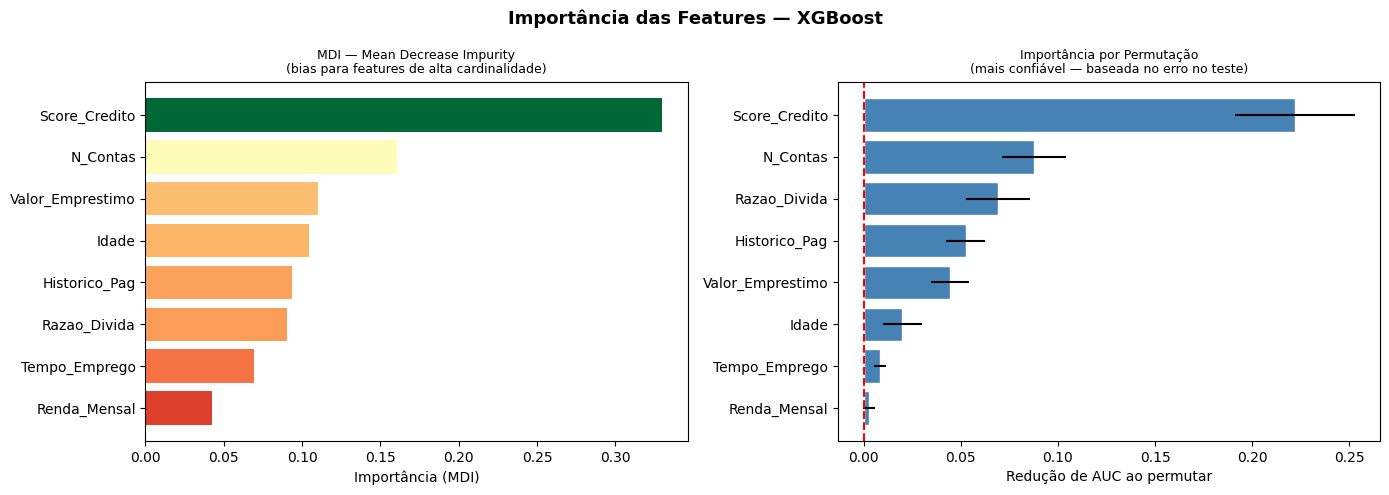

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)

# Dataset de decisões de crédito
X_cred, y_cred = make_classification(
    n_samples=1000, n_features=8, n_informative=6, n_redundant=1, 
    weights=[0.75, 0.25], random_state=42
)
feat_names = ['Score_Credito', 'Renda_Mensal', 'Razao_Divida', 'Tempo_Emprego',
               'N_Contas', 'Historico_Pag', 'Valor_Emprestimo', 'Idade']

X_df_cred = pd.DataFrame(X_cred, columns=feat_names)
X_tr, X_te, y_tr, y_te = train_test_split(X_df_cred, y_cred, test_size=0.25, 
                                             stratify=y_cred, random_state=42)

# Treinar modelo
try:
    import xgboost as xgb
    modelo = xgb.XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss', verbosity=0)
    modelo_nome = 'XGBoost'
except:
    modelo = GradientBoostingClassifier(n_estimators=100, random_state=42)
    modelo_nome = 'Gradient Boosting'

modelo.fit(X_tr, y_tr)
print(f"Modelo: {modelo_nome}")
print(f"AUC-ROC: {__import__('sklearn.metrics', fromlist=['roc_auc_score']).roc_auc_score(y_te, modelo.predict_proba(X_te)[:,1]):.4f}")

# Comparação de 3 tipos de importância
fi_mdi = modelo.feature_importances_  # MDI (para tree-based)
pi_result = permutation_importance(modelo, X_te, y_te, n_repeats=20, random_state=42, scoring='roc_auc')
fi_perm = pi_result.importances_mean

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'Importância das Features — {modelo_nome}', fontsize=13, fontweight='bold')

# MDI
idx_mdi = np.argsort(fi_mdi)
colors_mdi = plt.cm.RdYlGn(fi_mdi[idx_mdi]/fi_mdi.max())
axes[0].barh([feat_names[i] for i in idx_mdi], fi_mdi[idx_mdi], color=colors_mdi)
axes[0].set_title('MDI — Mean Decrease Impurity\n(bias para features de alta cardinalidade)', fontsize=9)
axes[0].set_xlabel('Importância (MDI)')

# Permutação
idx_perm = np.argsort(fi_perm)
axes[1].barh([feat_names[i] for i in idx_perm], fi_perm[idx_perm],
              xerr=pi_result.importances_std[idx_perm], color='steelblue', edgecolor='white')
axes[1].axvline(0, color='red', lw=1.5, linestyle='--')
axes[1].set_title('Importância por Permutação\n(mais confiável — baseada no erro no teste)', fontsize=9)
axes[1].set_xlabel('Redução de AUC ao permutar')

plt.tight_layout()
plt.savefig('../imagens/14_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

📊 PARTIAL DEPENDENCE PLOTS (PDP) E ICE


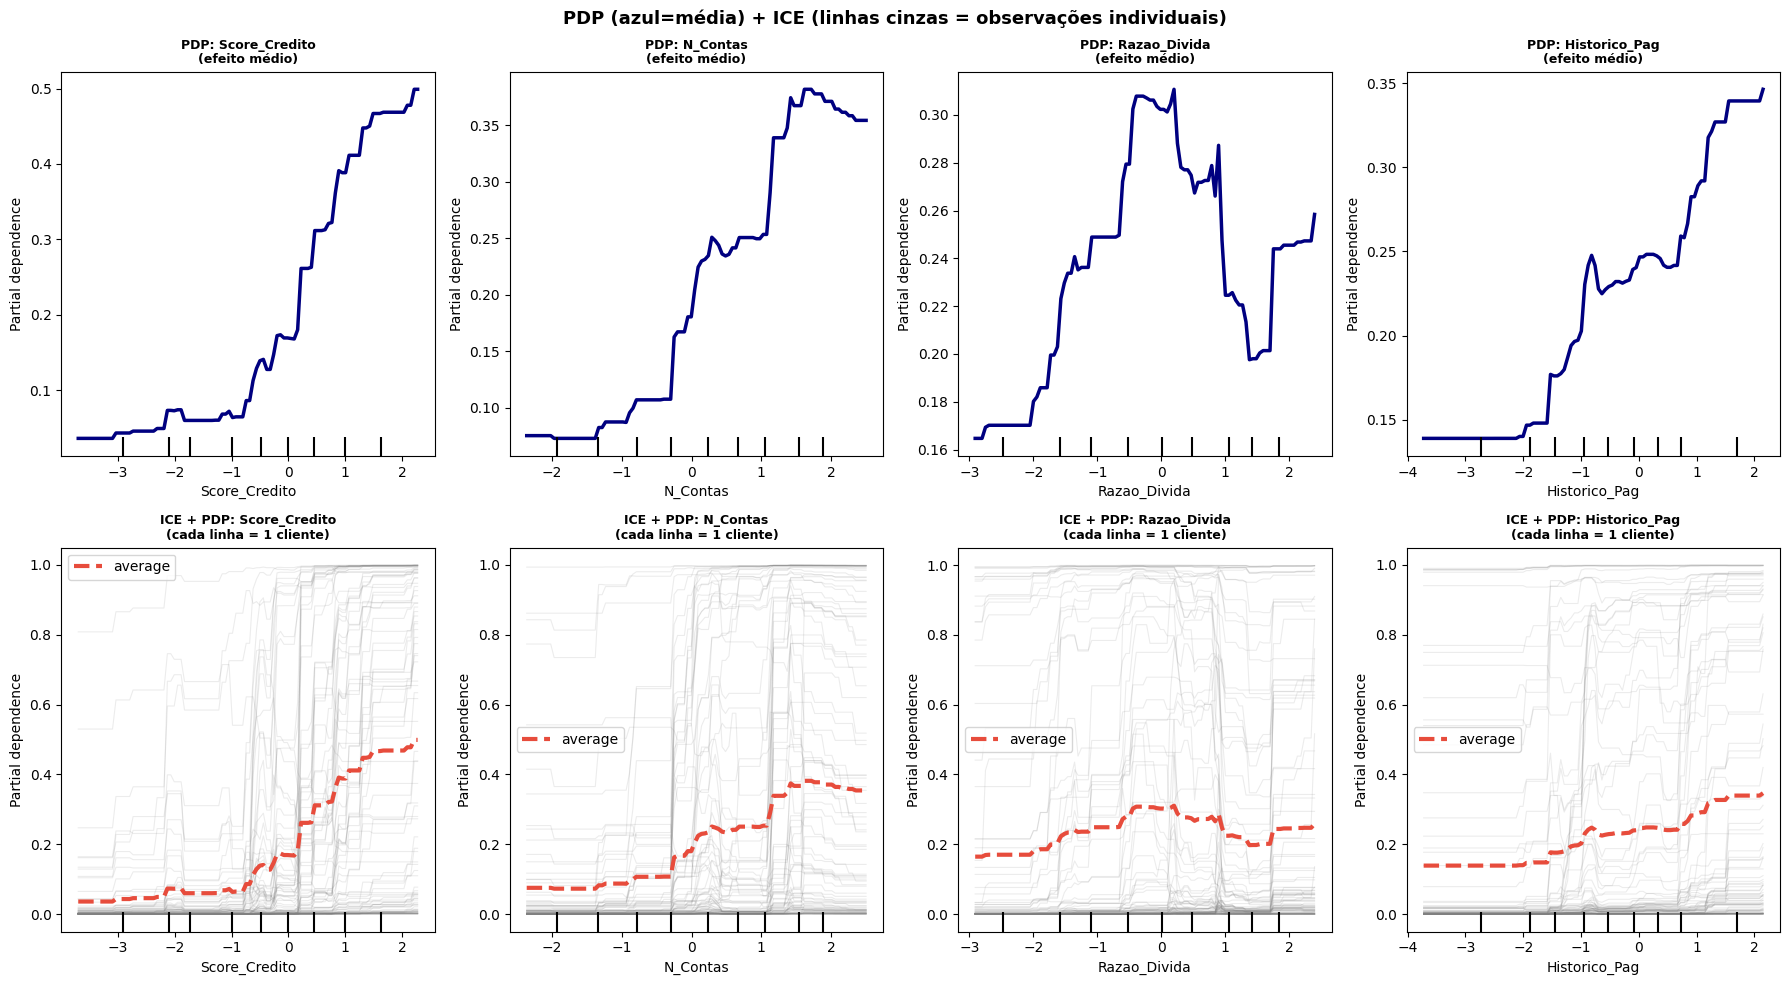


💡 ICE revela quando o efeito médio (PDP) esconde heterogeneidade!
   Linhas paralelas: efeito homogêneo. Linhas que se cruzam: interação!


In [2]:
from sklearn.inspection import PartialDependenceDisplay

print("=" * 55)
print("📊 PARTIAL DEPENDENCE PLOTS (PDP) E ICE")
print("=" * 55)

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
fig.suptitle('PDP (azul=média) + ICE (linhas cinzas = observações individuais)', 
             fontsize=13, fontweight='bold')

feat_idx_top = np.argsort(fi_perm)[::-1][:4]  # top 4 features

for col, feat_idx in enumerate(feat_idx_top):
    feat_nome = feat_names[feat_idx]
    
    # PDP
    display_pdp = PartialDependenceDisplay.from_estimator(
        modelo, X_te, features=[feat_idx], 
        kind='average', ax=axes[0, col],
        line_kw={'color': 'navy', 'lw': 2.5}
    )
    axes[0, col].set_title(f'PDP: {feat_nome}\n(efeito médio)', fontsize=9, fontweight='bold')
    axes[0, col].set_xlabel(feat_nome)
    
    # ICE (Individual Conditional Expectation)
    display_ice = PartialDependenceDisplay.from_estimator(
        modelo, X_te, features=[feat_idx],
        kind='both', ax=axes[1, col],
        ice_lines_kw={'color': 'gray', 'alpha': 0.15, 'lw': 0.8},
        pd_line_kw={'color': '#e74c3c', 'lw': 3},
        subsample=100
    )
    axes[1, col].set_title(f'ICE + PDP: {feat_nome}\n(cada linha = 1 cliente)', fontsize=9, fontweight='bold')
    axes[1, col].set_xlabel(feat_nome)

plt.tight_layout()
plt.savefig('../imagens/14_pdp_ice.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n💡 ICE revela quando o efeito médio (PDP) esconde heterogeneidade!")
print("   Linhas paralelas: efeito homogêneo. Linhas que se cruzam: interação!")

🎮 SHAP VALUES — EXPLICAÇÃO BASEADA EM TEORIA DOS JOGOS


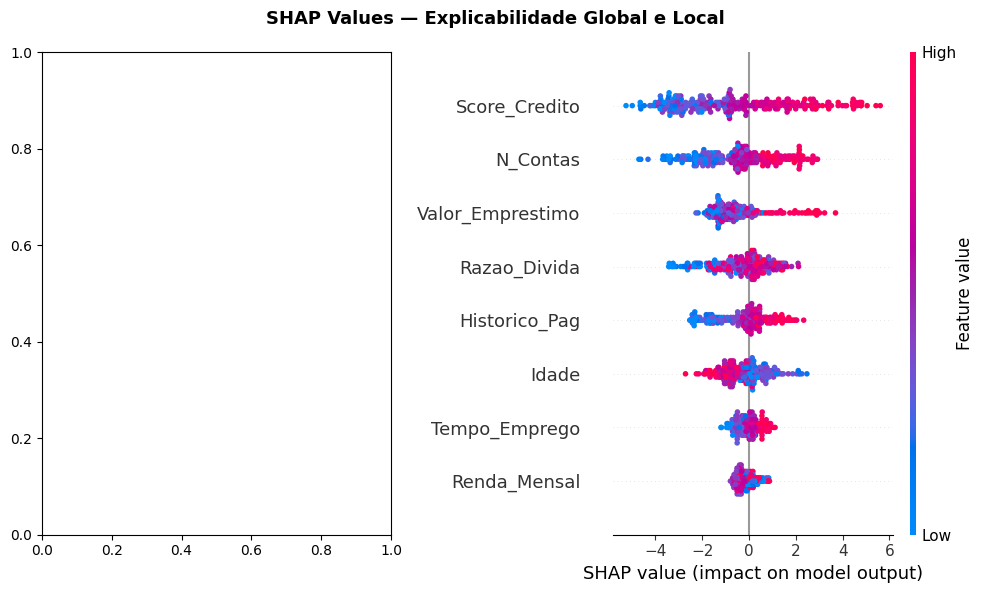

✅ SHAP Summary Plot gerado!


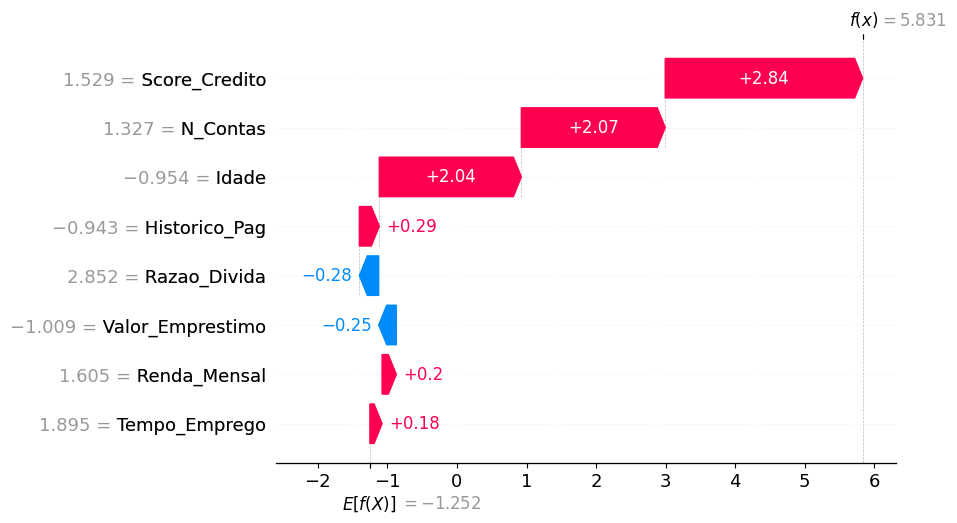

<Figure size 640x480 with 0 Axes>

✅ Waterfall para cliente 0: predição = 0.997


In [3]:
print("=" * 55)
print("🎮 SHAP VALUES — EXPLICAÇÃO BASEADA EM TEORIA DOS JOGOS")
print("=" * 55)

try:
    import shap
    
    explainer = shap.TreeExplainer(modelo)
    shap_values = explainer.shap_values(X_te)
    
    if isinstance(shap_values, list):
        sv = shap_values[1]  # classe positiva
    else:
        sv = shap_values
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle('SHAP Values — Explicabilidade Global e Local', fontsize=13, fontweight='bold')
    
    # Summary Plot (Beeswarm)
    shap.summary_plot(sv, X_te, feature_names=feat_names, show=False, plot_type='dot')
    plt.gcf().set_size_inches(10, 6)
    plt.tight_layout()
    plt.savefig('../imagens/14_shap_summary.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ SHAP Summary Plot gerado!")
    
    # Waterfall para observação específica
    shap.waterfall_plot(shap.Explanation(values=sv[0], base_values=explainer.expected_value 
                                           if not isinstance(explainer.expected_value, list) 
                                           else explainer.expected_value[1],
                                           data=X_te.iloc[0].values,
                                           feature_names=feat_names))
    plt.tight_layout()
    plt.savefig('../imagens/14_shap_waterfall.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✅ Waterfall para cliente 0: predição = {modelo.predict_proba(X_te.iloc[:1])[0,1]:.3f}")

except ImportError:
    print("SHAP não instalado. Usando aproximação manual...")
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Importância por permutação como proxy
    fi_shap_proxy = fi_perm
    idx_sorted = np.argsort(fi_shap_proxy)
    colors_shap = ['#e74c3c' if v > 0 else '#3498db' for v in fi_shap_proxy[idx_sorted]]
    ax.barh([feat_names[i] for i in idx_sorted], fi_shap_proxy[idx_sorted], color=colors_shap)
    ax.axvline(0, color='black', lw=1.5)
    ax.set_title('Importância por Permutação (proxy para SHAP)\nInstale: pip install shap', fontweight='bold')
    ax.set_xlabel('Impacto na AUC-ROC')
    plt.tight_layout()
    plt.savefig('../imagens/14_importancia_proxy.png', dpi=150, bbox_inches='tight')
    plt.show()

🍋 LIME — EXPLICAÇÃO LOCAL DE PREDIÇÕES INDIVIDUAIS


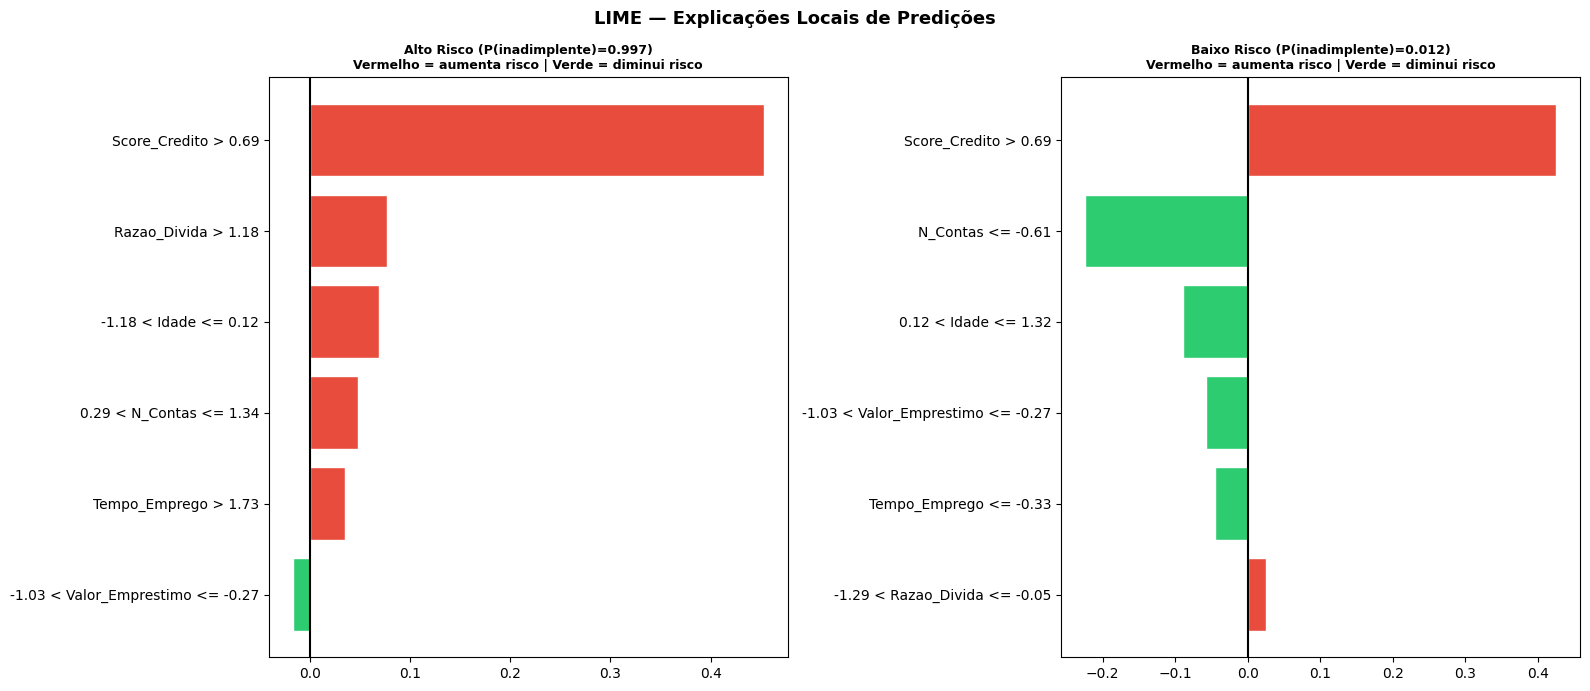

✅ Explicações LIME geradas!


In [4]:
print("=" * 55)
print("🍋 LIME — EXPLICAÇÃO LOCAL DE PREDIÇÕES INDIVIDUAIS")
print("=" * 55)

try:
    import lime
    import lime.lime_tabular
    
    explainer_lime = lime.lime_tabular.LimeTabularExplainer(
        X_tr.values, feature_names=feat_names, class_names=['Adimplente', 'Inadimplente'],
        discretize_continuous=True, random_state=42
    )
    
    # Explicar 2 predições
    idx_alto_risco = np.where(modelo.predict_proba(X_te)[:,1] > 0.8)[0][0]
    idx_baixo_risco = np.where(modelo.predict_proba(X_te)[:,1] < 0.1)[0][0]
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    fig.suptitle('LIME — Explicações Locais de Predições', fontsize=13, fontweight='bold')
    
    for ax, idx, titulo in zip(axes, [idx_alto_risco, idx_baixo_risco], 
                                  ['Alto Risco', 'Baixo Risco']):
        exp = explainer_lime.explain_instance(
            X_te.iloc[idx].values, modelo.predict_proba, num_features=6, num_samples=1000
        )
        exp_map = dict(exp.as_list())
        feats = list(exp_map.keys())[::-1]
        vals = [exp_map[f] for f in feats]
        cores_lime = ['#e74c3c' if v > 0 else '#2ecc71' for v in vals]
        ax.barh(feats, vals, color=cores_lime, edgecolor='white')
        ax.axvline(0, color='black', lw=1.5)
        pred_prob = modelo.predict_proba(X_te.iloc[[idx]])[0,1]
        ax.set_title(f'{titulo} (P(inadimplente)={pred_prob:.3f})\nVermelho = aumenta risco | Verde = diminui risco',
                      fontsize=9, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('../imagens/14_lime.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ Explicações LIME geradas!")

except ImportError:
    print("LIME não instalado. Execute: pip install lime")
    print("Mostrando manualmente a influência de cada feature...")
    
    base_pred = modelo.predict_proba(X_te)[:,1].mean()
    idx_exemplo = 0
    influencias = []
    
    for i, fname in enumerate(feat_names):
        X_perm = X_te.copy()
        X_perm.iloc[:, i] = X_te.iloc[:, i].mean()
        nova_pred = modelo.predict_proba(X_te.iloc[[idx_exemplo]])[0,1]
        influencias.append(fi_perm[i] * np.sign(X_te.iloc[idx_exemplo, i]))
    
    fig, ax = plt.subplots(figsize=(10, 5))
    cores_inf = ['#e74c3c' if v > 0 else '#2ecc71' for v in influencias]
    idx_sorted = np.argsort(influencias)
    ax.barh([feat_names[i] for i in idx_sorted], [influencias[i] for i in idx_sorted], 
             color=[cores_inf[i] for i in idx_sorted], edgecolor='white')
    ax.axvline(0, color='black', lw=1.5)
    ax.set_title('Aproximação LIME manual\nInstale: pip install lime', fontweight='bold')
    plt.tight_layout()
    plt.savefig('../imagens/14_lime_manual.png', dpi=150, bbox_inches='tight')
    plt.show()

## 7. Resumo e Exercícios

### LIME vs SHAP — Qual Usar?

| Critério | LIME | SHAP |
|----------|------|------|
| Velocidade | Rápido | Médio a lento |
| Consistência | Pode variar (estocástico) | Consistente (axiomático) |
| Escopo | Apenas local | Local e global |
| Base teórica | Aproximação linear local | Teoria dos jogos (Shapley) |
| Suporte a modelos | Todos (agnóstico) | Otimizado para trees, agnóstico geral |
| Facilidade de interpretação | Alta | Alta (waterfall, beeswarm) |

### Global vs Local

- **Interpretação Global**: entende o modelo como um todo (Feature Importance, PDP, SHAP summary)
- **Interpretação Local**: explica uma predição específica (LIME, SHAP waterfall, ICE individual)

### Casos de Uso na Prática

| Aplicação | Técnica Recomendada | Por quê? |
|-----------|--------------------|---------|
| Auditoria de modelo (LGPD/GDPR) | SHAP global | Consistente, auditável |
| Explicar decisão de crédito ao cliente | LIME ou SHAP waterfall | Explicação individual clara |
| Debug de modelo com performance ruim | Permutation Importance + PDP | Entender o que o modelo aprendeu |
| Detecção de viés/discriminação | PDP + ICE por grupo | Revelar disparidades |
| Modelo médico (diagnóstico) | SHAP + validação com especialistas | Confiança e safety |

### Boas Práticas de XAI
1. **Use múltiplas técnicas**: nenhuma sozinha é suficiente
2. **Valide com especialistas do domínio**: a interpretação deve fazer sentido prático
3. **Cuidado com PDP em features correlacionadas**: pode gerar combinações impossíveis
4. **SHAP é axiomático** (eficiência, simetria, nulidade, aditividade) — prefira-o para auditoria
5. **ICE antes de PDP**: sempre cheque se o efeito médio é representativo

---

### Exercícios

1. **Exercício 1 — Comparação MDI vs Permutação**: Treine um RandomForest no dataset `diabetes` do sklearn. Compare as feature importances por MDI e por permutação. Há diferenças significativas? Por quê?

2. **Exercício 2 — PDP 2D**: Use `PartialDependenceDisplay` com `features=[(i, j)]` para criar um PDP bidimensional das 2 features mais importantes. O que você observa?

3. **Exercício 3 — SHAP Force Plot**: Instale shap (`pip install shap`). Gere um force plot para os 5 clientes com maior probabilidade de inadimplência. Quais features são mais responsáveis?

4. **Desafio — Detecção de Viés**: Use um dataset com variável protegida (gênero, raça). Treine um modelo e use SHAP para verificar se a variável protegida (ou proxies dela) tem impacto significativo nas predições. Como mitigar isso?